# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Chyntia Claudia
- Email: chyntiaclaudia1809@gmail.com
- Id Dicoding:CDCC319D6X2689

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import joblib

pd.set_option('display.max_columns', None)

Dataset yang saya gunakan pada proyek ini berasal dari Jaya Jaya Institut, berisi data siswa mulai dari kondisi demografi, latar belakang sosial-ekonomi, jalur akademik saat pendaftaran, hingga performa akademik pada semester 1 dan semester 2. 

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Business Understanding

Jaya Jaya Institut merupakan institusi pendidikan perguruan tinggi yang telah berdiri sejak tahun 2000 dan sejauh ini telah mencetak banyak lulusan dengan reputasi baik. Namun di balik pencapaian tersebut, institusi ini masih menghadapi masalah serius: tingginya angka siswa yang tidak menyelesaikan pendidikannya alias dropout. Bagi sebuah institusi pendidikan, tingkat dropout yang tinggi bukan hanya soal angka, tapi berdampak langsung pada reputasi institusi, efisiensi biaya operasional, serta yang paling penting, masa depan siswa itu sendiri.

Saat ini pihak institusi baru bisa mengetahui siswa berisiko dropout setelah kondisinya sudah cukup parah, sehingga bimbingan khusus yang diberikan seringkali terlambat. Oleh karena itu, saya akan membantu Jaya Jaya Institut membangun sebuah sistem yang dapat mendeteksi potensi dropout siswa sedini mungkin, berdasarkan data yang mereka miliki sejak siswa mendaftar hingga performa akademik semester awal.

### Permasalahan Bisnis

Berdasarkan latar belakang di atas, permasalahan yang akan saya jawab dalam proyek ini adalah:
- Faktor apa saja yang paling berpengaruh terhadap potensi dropout siswa di Jaya Jaya Institut?
- Bagaimana cara memprediksi status siswa (Dropout atau Graduate) berdasarkan data demografi, sosial-ekonomi, dan performa akademik mereka?
- Bagaimana pihak institusi dapat memonitor performa siswa secara berkelanjutan agar bisa memberikan intervensi lebih cepat?

### Cakupan Proyek

Untuk menjawab permasalahan tersebut, ruang lingkup proyek yang saya kerjakan meliputi:
1. Melakukan eksplorasi data (EDA) untuk memahami karakteristik dan pola pada data siswa.
2. Melakukan data preparation agar data siap digunakan untuk pemodelan.
3. Membangun model machine learning untuk mengklasifikasikan status siswa ke dalam tiga kategori: Dropout, Enrolled, dan Graduate.
4. Mengevaluasi performa model yang dibangun.
5. Membuat dashboard bisnis untuk membantu pihak institusi memonitor performa dan faktor risiko siswa.
6. Membangun prototype sistem prediksi berbasis Streamlit dan men-deploy-nya agar dapat diakses secara online.

## Data Understanding

Sebelum masuk ke tahap pembersihan data, saya perlu memahami dulu struktur dan kondisi data yang saya miliki. Pada tahap ini saya akan memeriksa jumlah baris dan kolom, tipe data pada setiap kolom, ada tidaknya missing value, serta melihat gambaran umum sebaran nilai pada tiap fitur. Pemahaman ini penting agar saya bisa menentukan langkah data preparation yang tepat di tahap selanjutnya.

In [3]:
df.shape

(4424, 37)

Dataset ini terdiri dari 4424 baris data siswa dengan 37 kolom, terdiri dari 36 fitur dan 1 kolom target (`Status`) yang menunjukkan apakah siswa tersebut Dropout, Enrolled, atau Graduate.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

Setelah melihat tipe data setiap kolom, saya ingin memastikan tidak ada nilai yang hilang pada dataset ini sebelum masuk ke tahap analisis lebih lanjut.

In [5]:
df.isnull().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


Berdasarkan hasil pengecekan ini, saya akan melihat apakah ada kolom yang memiliki missing value. Jika ada, saya perlu menentukan strategi penanganannya di tahap Data Preparation nanti, apakah akan saya hapus, isi dengan nilai tertentu, atau saya biarkan tergantung proporsi dan relevansinya terhadap analisis.

Saya juga ingin melihat ringkasan statistik dari seluruh kolom numerik untuk memahami rentang nilai, rata-rata, dan sebaran data secara umum.

In [6]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,10.960895,11.032324,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,26.418253,25.263040,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,4.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,7.000000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,9.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,195.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


Selanjutnya saya ingin melihat proporsi masing-masing kelas pada kolom target (Status), untuk memastikan apakah data ini seimbang atau tidak sebelum saya lanjutkan ke tahap pemodelan.

In [7]:
df['Status'].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Setelah memahami struktur data secara umum, saya tidak menemukan missing value pada dataset ini sehingga saya bisa langsung fokus ke eksplorasi pola. Saya juga melihat bahwa distribusi kelas target cukup imbang meski Graduate mendominasi. Graduate 49.9%, Dropout 32.1%, dan Enrolled 17.9%. Selanjutnya saya akan menggali lebih dalam faktor-faktor apa saja yang berkaitan dengan status siswa, terutama yang membedakan siswa Dropout dari yang lain.

C:\Users\HYPE AMD\AppData\Local\Temp\ipykernel_1804\3734271679.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', order=df['Status'].value_counts().index, palette='viridis')


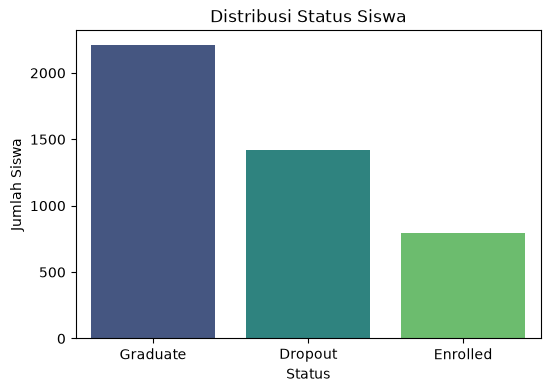

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Status', order=df['Status'].value_counts().index, palette='viridis')
plt.title('Distribusi Status Siswa')
plt.xlabel('Status')
plt.ylabel('Jumlah Siswa')
plt.show()

Untuk mempermudah interpretasi visualisasi selanjutnya, saya membuat salinan dataset dan mengubah beberapa kolom kategorikal yang masih berupa kode angka menjadi label yang lebih mudah dibaca, seperti jenis kelamin dan status pembayaran.

In [9]:
df_eda = df.copy()

df_eda['Gender'] = df_eda['Gender'].map({1: 'Laki-laki', 0: 'Perempuan'})
df_eda['Scholarship_holder'] = df_eda['Scholarship_holder'].map({1: 'Ya', 0: 'Tidak'})
df_eda['Debtor'] = df_eda['Debtor'].map({1: 'Ya', 0: 'Tidak'})
df_eda['Tuition_fees_up_to_date'] = df_eda['Tuition_fees_up_to_date'].map({1: 'Lunas', 0: 'Belum Lunas'})
df_eda['Displaced'] = df_eda['Displaced'].map({1: 'Ya', 0: 'Tidak'})

Saya mencurigai beberapa faktor sosial-ekonomi seperti status pembayaran uang kuliah, status penerima beasiswa, dan status debitur punya kaitan erat dengan potensi dropout. Berikut saya coba visualisasikan hubungan masing-masing faktor tersebut dengan status siswa.

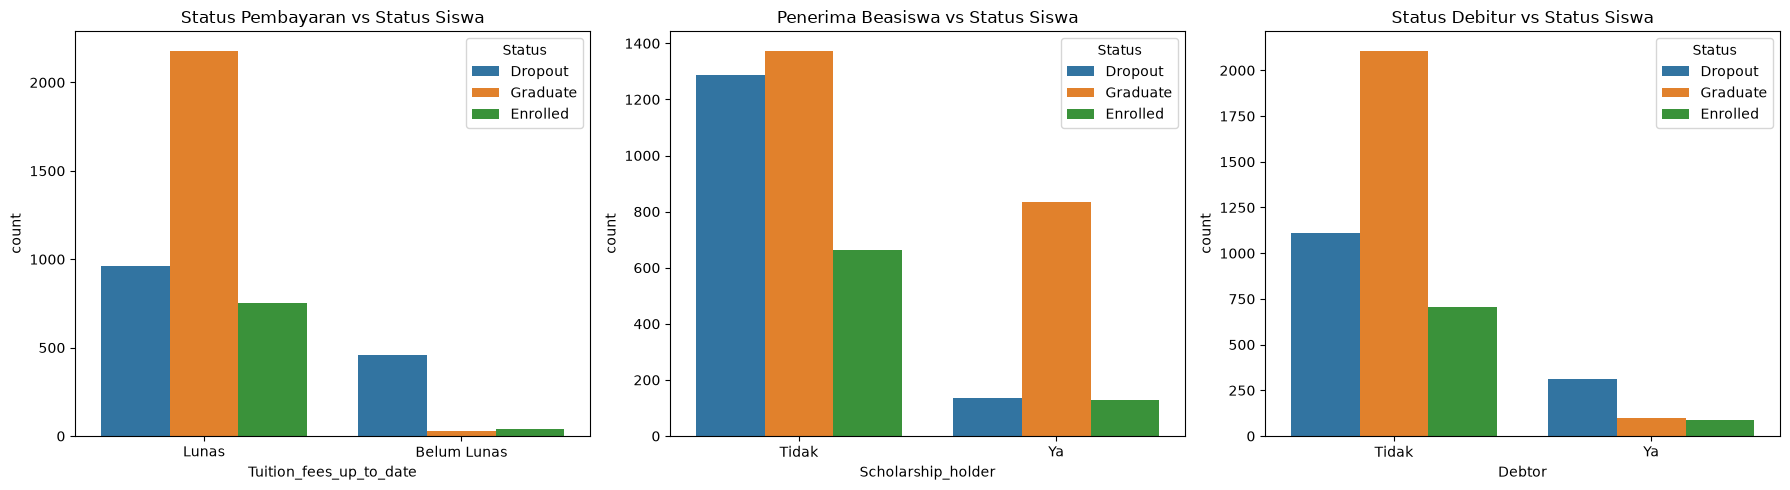

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(data=df_eda, x='Tuition_fees_up_to_date', hue='Status', ax=axes[0])
axes[0].set_title('Status Pembayaran vs Status Siswa')

sns.countplot(data=df_eda, x='Scholarship_holder', hue='Status', ax=axes[1])
axes[1].set_title('Penerima Beasiswa vs Status Siswa')

sns.countplot(data=df_eda, x='Debtor', hue='Status', ax=axes[2])
axes[2].set_title('Status Debitur vs Status Siswa')

plt.tight_layout()
plt.show()

Grafik di atas menunjukkan pola yang cukup mencolok: siswa yang belum melunasi uang kuliah ("Belum Lunas") hampir seluruhnya berstatus Dropout, sementara pada siswa yang sudah lunas, proporsi Graduate jauh lebih dominan. Pola serupa juga terlihat pada status penerima beasiswa dan status debitur, meski tidak setajam pola pembayaran uang kuliah. Temuan ini menegaskan bahwa faktor finansial merupakan salah satu sinyal risiko dropout yang paling kuat pada dataset ini, dan akan menjadi salah satu insight utama yang saya angkat pada dashboard dan rekomendasi bisnis nantinya.

Selain faktor sosial-ekonomi, saya juga ingin melihat bagaimana performa akademik siswa pada semester 1 dan semester 2 berbeda antar status siswa.

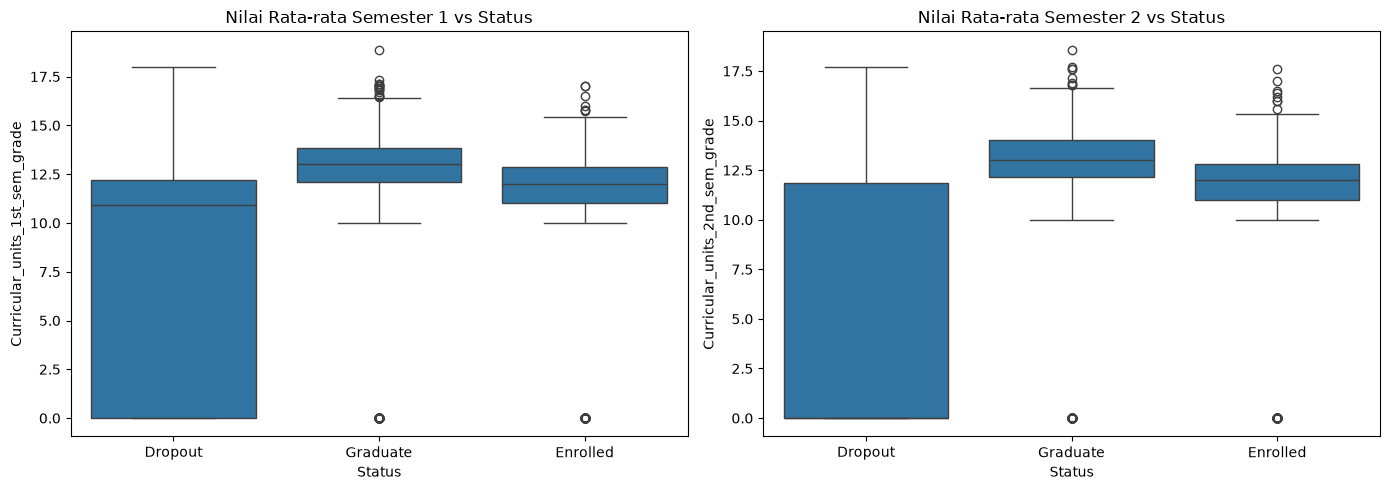

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df_eda, x='Status', y='Curricular_units_1st_sem_grade', ax=axes[0])
axes[0].set_title('Nilai Rata-rata Semester 1 vs Status')

sns.boxplot(data=df_eda, x='Status', y='Curricular_units_2nd_sem_grade', ax=axes[1])
axes[1].set_title('Nilai Rata-rata Semester 2 vs Status')

plt.tight_layout()
plt.show()

Boxplot ini memperlihatkan bahwa median nilai siswa dengan status Dropout jauh lebih rendah dan sebarannya jauh lebih lebar dibanding Enrolled maupun Graduate, bahkan turun hingga ke titik 0 pada kedua semester. Saya menduga hal ini bukan semata-mata karena siswa Dropout memiliki kemampuan akademik yang buruk, melainkan karena sebagian dari mereka kemungkinan besar berhenti kuliah sebelum sempat dievaluasi sama sekali pada semester tersebut, sehingga nilainya tercatat 0. Temuan ini penting agar saya tidak salah menyimpulkan hubungan sebab-akibat pada tahap Conclusion nanti.

Saya juga ingin melihat gambaran korelasi antar variabel numerik untuk memastikan tidak ada fitur yang saling tumpang tindih secara ekstrem sebelum saya bawa ke tahap pemodelan.

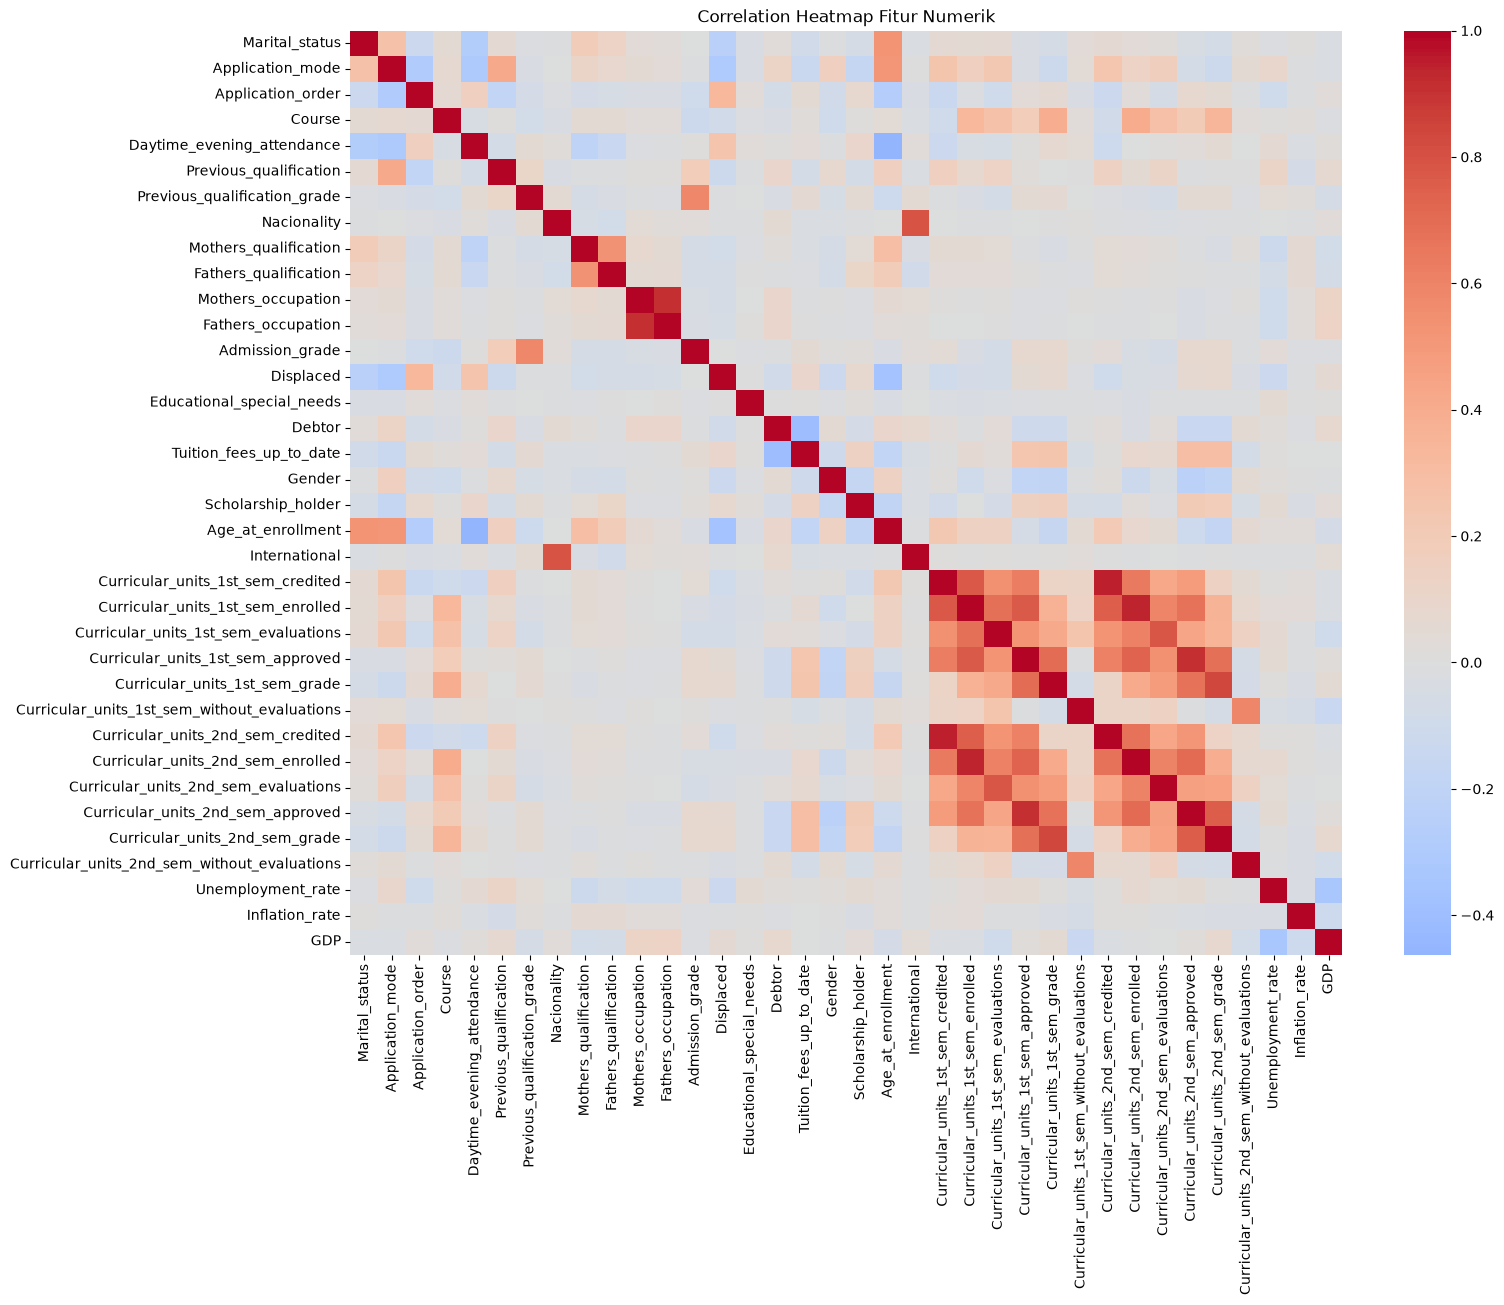

In [12]:
plt.figure(figsize=(16,12))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap Fitur Numerik')
plt.show()

Dari heatmap ini terlihat bahwa korelasi tertinggi terjadi pada fitur-fitur dalam kelompok yang sama, misalnya antar variabel `Curricular_units_1st_sem_*` dan antar variabel `Curricular_units_2nd_sem_*`. Hal ini wajar karena variabel-variabel tersebut memang secara alami saling terkait (jumlah SKS yang diambil, dievaluasi, dan disetujui). Karena saya berencana menggunakan model berbasis pohon keputusan seperti Random Forest yang relatif tidak terganggu oleh multikolinearitas, saya memutuskan untuk tetap menyertakan seluruh fitur ini pada tahap pemodelan tanpa perlu melakukan reduksi dimensi.

## Data Preparation / Preprocessing

Setelah memahami pola-pola pada data, saya masuk ke tahap mempersiapkan data agar siap digunakan untuk pemodelan. Karena target saya berupa data kategorikal (Dropout, Enrolled, Graduate), saya perlu mengubahnya menjadi bentuk numerik terlebih dahulu. Saya juga akan membagi data menjadi data latih dan data uji, serta melakukan penskalaan (scaling) pada fitur numerik agar setiap fitur memiliki rentang nilai yang sebanding, mengingat beberapa algoritma machine learning sensitif terhadap perbedaan skala antar fitur.

Pada tahap awal saya sempat melatih model menggunakan seluruh tiga kelas target (Dropout, Enrolled, Graduate). Namun setelah dievaluasi ulang, saya menyadari bahwa pendekatan ini kurang tepat secara konsep. Status Enrolled merepresentasikan siswa yang masih aktif berkuliah dan belum memiliki hasil akhir, sehingga jika dilibatkan sebagai kelas pada saat training, target model menjadi tidak jelas dan berpotensi menurunkan validitas prediksi. Oleh karena itu, saya memutuskan untuk memfokuskan proses pemodelan hanya pada siswa dengan status akhir yang sudah pasti, yaitu Dropout dan Graduate. Data siswa dengan status Enrolled tetap saya manfaatkan, namun hanya pada tahap inferensi di akhir notebook, untuk memprediksi potensi hasil akhir mereka, bukan sebagai data latih.

In [13]:
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
print("Jumlah data sebelum filter:", df.shape[0])
print("Jumlah data setelah filter (Dropout & Graduate):", df_model.shape[0])
df_model['Status'].value_counts()

Jumlah data sebelum filter: 4424
Jumlah data setelah filter (Dropout & Graduate): 3630


Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Setelah data difilter agar hanya mencakup siswa dengan status akhir yang pasti, saya melanjutkan proses encoding target ke bentuk numerik.

In [14]:
le = LabelEncoder()
df_model['Status_encoded'] = le.fit_transform(df_model['Status'])

dict(zip(le.classes_, le.transform(le.classes_)))

{'Dropout': np.int64(0), 'Graduate': np.int64(1)}

Saya menyimpan hasil encoding target ini pada kolom baru `Status_encoded` agar kolom `Status` asli tetap bisa saya gunakan untuk keperluan interpretasi. Berikutnya saya memisahkan fitur (X) dan target (y) dari `df_model`, lalu membagi data menjadi data latih dan data uji dengan proporsi 80:20.

In [15]:
X = df_model.drop(columns=['Status', 'Status_encoded'])
y = df_model['Status_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((2904, 36), (726, 36))

Karena beberapa fitur numerik memiliki skala yang jauh berbeda (misalnya GDP dan Admission_grade), saya melakukan standardisasi menggunakan StandardScaler agar setiap fitur memiliki kontribusi yang seimbang saat model dilatih.

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

Pada tahap ini saya akan membangun model klasifikasi untuk memprediksi status siswa. Saya memulai dengan model Logistic Regression sebagai baseline karena sederhana dan cepat dilatih, sehingga bisa menjadi acuan pembanding. Setelah itu saya akan mencoba Random Forest, karena model berbasis pohon keputusan ini umumnya lebih mampu menangkap hubungan non-linear antar fitur dan tidak terlalu terganggu oleh multikolinearitas yang saya temukan di tahap Data Understanding.

In [17]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
print("Akurasi Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Akurasi Logistic Regression: 0.9146005509641874


Setelah mendapatkan baseline, saya mencoba Random Forest. Model ini tidak memerlukan data yang telah di-scaling, sehingga saya menggunakan data hasil split asli (belum distandardisasi) untuk melatihnya.

In [18]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Akurasi Random Forest:", accuracy_score(y_test, y_pred_rf))

Akurasi Random Forest: 0.9118457300275482


## Evaluation

Akurasi keseluruhan kedua model kali ini jauh lebih tinggi dibanding saat saya masih melibatkan tiga kelas status sekaligus. Karena target sekarang sudah lebih jelas (hanya Dropout dan Graduate), saya ingin melihat lebih detail performa masing-masing model menggunakan classification report dan confusion matrix, khususnya pada recall kelas Dropout yang menjadi fokus utama permasalahan bisnis ini.

In [19]:
target_names = ['Dropout', 'Graduate']

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=target_names))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

=== Logistic Regression ===
              precision    recall  f1-score   support

     Dropout       0.94      0.84      0.88       284
    Graduate       0.90      0.96      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.91      0.91       726

=== Random Forest ===
              precision    recall  f1-score   support

     Dropout       0.95      0.81      0.88       284
    Graduate       0.89      0.98      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.92      0.91      0.91       726



Hasil classification report menunjukkan peningkatan performa yang signifikan dibanding pendekatan sebelumnya saat masih melibatkan tiga kelas. Logistic Regression mencapai akurasi 91.46% dengan recall Dropout sebesar 0.84 dan presisi 0.94, sedikit lebih baik dibanding Random Forest yang mencapai akurasi 91.18% dengan recall Dropout 0.81 dan presisi 0.95. Karena recall Dropout menjadi prioritas bisnis utama dan Logistic Regression unggul pada metrik ini sekaligus lebih sederhana secara komputasi, saya memilih Logistic Regression sebagai model final.

Selain melihat classification report, saya ingin memvisualisasikan confusion matrix dari kedua model untuk memahami pola kesalahan prediksi secara lebih rinci, khususnya kelas mana yang paling sering tertukar satu sama lain.

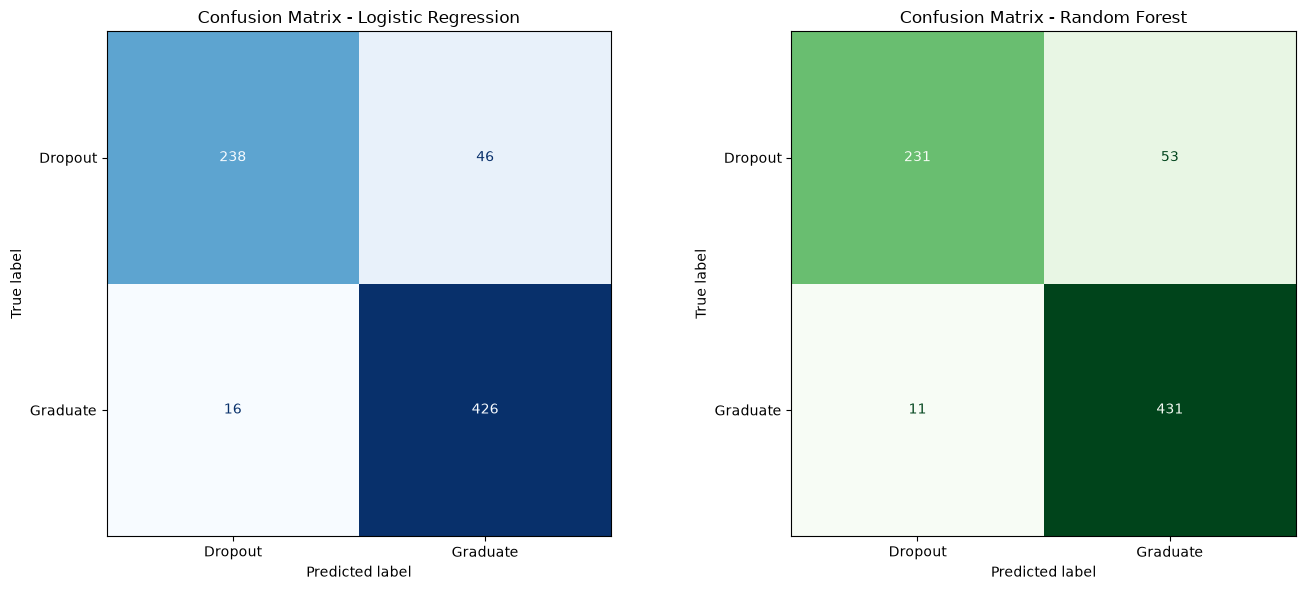

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=target_names).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Logistic Regression')

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=target_names).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix - Random Forest')

plt.tight_layout()
plt.show()

Dari confusion matrix, Logistic Regression salah mengklasifikasikan 46 siswa Dropout sebagai Graduate dan 16 siswa Graduate sebagai Dropout. Sementara itu, Random Forest salah mengklasifikasikan lebih banyak siswa Dropout sebagai Graduate, yaitu 53 siswa, meski jumlah kesalahan pada arah sebaliknya sedikit lebih rendah (11 siswa). Karena kesalahan memprediksi siswa Dropout sebagai Graduate merupakan kesalahan yang paling berisiko secara bisnis, hasil ini memperkuat keputusan saya untuk memilih Logistic Regression sebagai model final.

Sebagai langkah terakhir pada tahap evaluasi awal, saya ingin melihat fitur-fitur apa saja yang paling berkontribusi terhadap prediksi model Random Forest, untuk memvalidasi apakah temuan pada tahap Data Understanding sejalan dengan apa yang dipelajari oleh model.

C:\Users\HYPE AMD\AppData\Local\Temp\ipykernel_1804\2727169358.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette='mako')


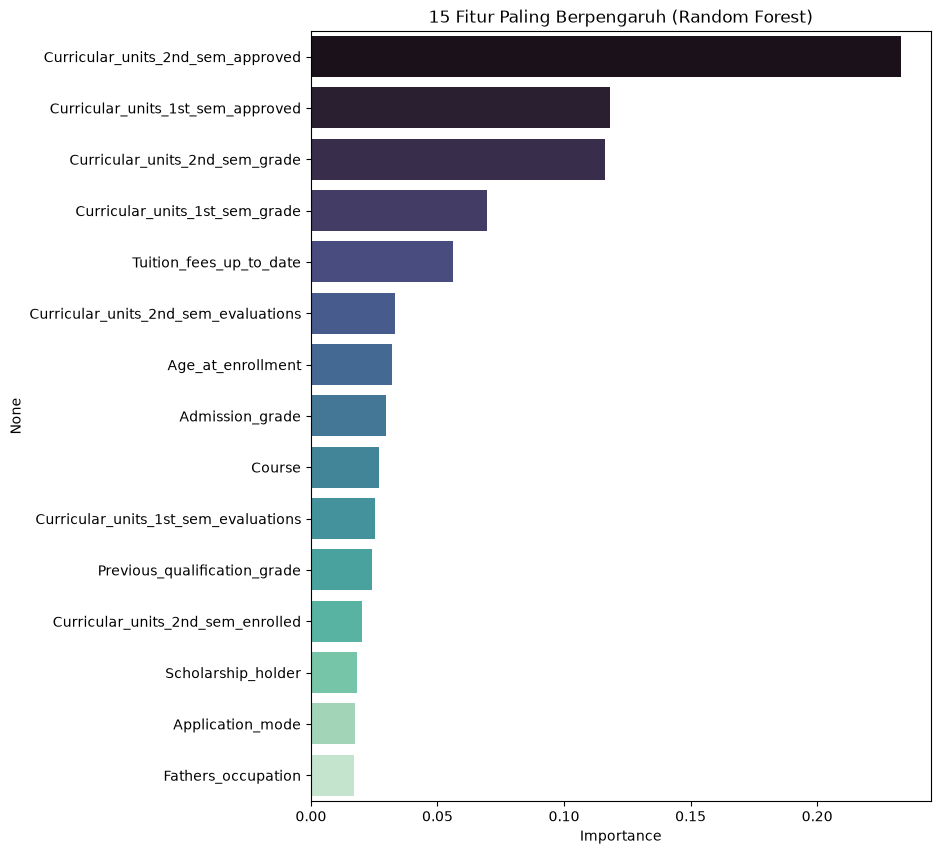

In [21]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette='mako')
plt.title('15 Fitur Paling Berpengaruh (Random Forest)')
plt.xlabel('Importance')
plt.show()

Feature importance ini mengonfirmasi temuan saya pada tahap Data Understanding. Fitur yang berkaitan dengan jumlah SKS yang disetujui dan nilai rata-rata pada semester 1 dan 2 berada jauh di posisi teratas, diikuti oleh status pembayaran uang kuliah. Artinya, performa akademik semester awal dan kondisi finansial siswa memang merupakan dua sinyal risiko dropout yang paling dapat diandalkan, baik dari sisi eksplorasi data maupun dari sisi model itu sendiri.

Berdasarkan hasil evaluasi di atas, saya memutuskan menggunakan Logistic Regression sebagai model final, karena memberikan akurasi tertinggi (91.46%) sekaligus recall Dropout terbaik (0.84) dibandingkan Random Forest. Karena distribusi kelas pada data yang sudah difilter ini jauh lebih seimbang dibanding sebelumnya (1421 Dropout berbanding 2209 Graduate), saya tidak perlu menerapkan teknik penyeimbangan tambahan seperti class_weight='balanced'. Selanjutnya saya menyimpan model, scaler, dan label encoder agar dapat digunakan pada prototype sistem prediksi.

In [22]:
joblib.dump(log_reg, 'model/model_lr.joblib')
joblib.dump(scaler, 'model/scaler.joblib')
joblib.dump(le, 'model/label_encoder.joblib')

print("Model, scaler, dan label encoder berhasil disimpan.")

Model, scaler, dan label encoder berhasil disimpan.


Sebagai pemanfaatan tambahan, saya menggunakan model ini untuk memprediksi potensi hasil akhir pada siswa yang saat ini berstatus Enrolled. Ini murni sebagai inferensi, bukan bagian dari proses training, karena status akhir siswa-siswa ini belum diketahui secara pasti.

In [23]:
df_enrolled = df[df['Status'] == 'Enrolled'].copy()
X_enrolled = df_enrolled.drop(columns=['Status'])
X_enrolled_scaled = scaler.transform(X_enrolled)

pred_enrolled = log_reg.predict(X_enrolled_scaled)
pred_label = le.inverse_transform(pred_enrolled)

pd.Series(pred_label, name='Prediksi Potensi Status Akhir').value_counts()

Prediksi Potensi Status Akhir
Graduate    442
Dropout     352
Name: count, dtype: int64

Dari 794 siswa yang saat ini berstatus Enrolled, model memprediksi 442 siswa berpotensi Graduate dan 352 siswa berpotensi Dropout. Hasil ini bisa menjadi masukan awal bagi Jaya Jaya Institut untuk memprioritaskan bimbingan kepada siswa aktif yang diprediksi berisiko dropout, sebelum status akhir mereka benar-benar terjadi.

## Conclusion

Berdasarkan seluruh proses yang telah saya lakukan, saya menemukan bahwa status pembayaran uang kuliah dan performa akademik pada semester 1 dan 2 (jumlah mata kuliah yang disetujui serta nilai rata-rata) merupakan faktor paling berpengaruh terhadap potensi dropout siswa di Jaya Jaya Institut. Siswa yang belum melunasi uang kuliah menunjukkan proporsi dropout yang jauh lebih tinggi dibanding siswa yang sudah lunas.

Model Logistic Regression yang saya pilih sebagai model final, dilatih hanya menggunakan data siswa dengan status akhir Dropout dan Graduate, mampu mencapai akurasi sebesar 91.46% dengan recall Dropout sebesar 0.84 dan presisi 0.94. Hasil ini jauh lebih baik dibandingkan pendekatan awal yang sempat saya coba dengan melibatkan tiga kelas status sekaligus, karena target yang digunakan kini merepresentasikan hasil akhir siswa yang sudah pasti, bukan status yang masih dapat berubah.

Sebagai pemanfaatan tambahan, saya juga menggunakan model ini untuk melakukan inferensi pada data siswa yang saat ini berstatus Enrolled. Dari 794 siswa aktif, model memprediksi 442 siswa berpotensi Graduate dan 352 siswa berpotensi Dropout, yang dapat menjadi masukan awal bagi pihak institusi untuk memprioritaskan bimbingan kepada siswa aktif yang diprediksi berisiko dropout.

In [ ]:
df_dashboard = df.copy()

df_dashboard['Gender_Label'] = df_dashboard['Gender'].map({1: 'Laki-laki', 0: 'Perempuan'})
df_dashboard['Tuition_Label'] = df_dashboard['Tuition_fees_up_to_date'].map({1: 'Lunas', 0: 'Belum Lunas'})
df_dashboard['Scholarship_Label'] = df_dashboard['Scholarship_holder'].map({1: 'Ya', 0: 'Tidak'})
df_dashboard['Debtor_Label'] = df_dashboard['Debtor'].map({1: 'Ya', 0: 'Tidak'})
df_dashboard['Displaced_Label'] = df_dashboard['Displaced'].map({1: 'Ya', 0: 'Tidak'})
df_dashboard['Attendance_Label'] = df_dashboard['Daytime_evening_attendance'].map({1: 'Siang', 0: 'Malam'})

course_map = {
    33: "Biofuel Production Technologies", 171: "Animation and Multimedia Design",
    8014: "Social Service (evening)", 9003: "Agronomy", 9070: "Communication Design",
    9085: "Veterinary Nursing", 9119: "Informatics Engineering", 9130: "Equinculture",
    9147: "Management", 9238: "Social Service", 9254: "Tourism", 9500: "Nursing",
    9556: "Oral Hygiene", 9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication", 9853: "Basic Education", 9991: "Management (evening)"
}
df_dashboard['Course_Label'] = df_dashboard['Course'].map(course_map)

df_dashboard.to_csv('data_dashboard.csv', index=False)
print("File data_dashboard.csv berhasil dibuat, siap diupload ke Google Sheets / Looker Studio.")

File data_dashboard.csv berhasil dibuat, siap diupload ke Google Sheets / Looker Studio.


Untuk keperluan pembuatan dashboard, saya membuat salinan dataset dengan tambahan kolom berlabel deskriptif (misalnya "Laki-laki"/"Perempuan" alih-alih kode 0/1) agar visualisasi pada dashboard lebih mudah dipahami oleh pihak non-teknis di Jaya Jaya Institut.